# HyDE (Hypothetical Document Embedding) 실험

HyDE(Hypothetical Document Embeddings)는 **사용자 질문에 대해 LLM(대형 언어 모델)로 가상의 문서를 먼저 생성하고, 이 문서를 임베딩하여 검색하는 방식**이다.  
기존에는 질문 자체를 임베딩해 유사한 문서를 찾았지만, HyDE는 질문의 맥락과 의도를 더 잘 반영할 수 있는 가상 문서를 생성해 임베딩하고, 이를 벡터 DB에서 비교함으로써 **더 정확한 검색 결과**를 얻을 수 있다.

**핵심 요약**
- 질문 → LLM이 가상 문서 생성 → 임베딩 → 벡터 DB에서 유사도 검색
- 기존 방식보다 **질문의 의미와 맥락을 더 잘 반영**하여 검색 정확도 향상
- RAG 등 다양한 검색·생성 AI 시스템에서 활용 가능
- 단점: LLM 사용으로 **속도가 느려질 수 있음**

In [2]:
from dotenv import load_dotenv
import os

load_dotenv()
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')
os.environ['PINECONE_API_KEY'] = os.getenv('PINECONE_API_KEY')

os.environ['LANGSMITH_TRACING'] = 'true'
os.environ['LANGSMITH_ENDPOINT'] = 'https://apac.api.smith.langchain.com'
os.environ['LANGSMITH_PROJECT'] = 'skn34-langchain'
os.environ['LANGSMITH_API_KEY'] = os.getenv('LANGSMITH_API_KEY')

In [3]:
import pandas as pd

document_df = pd.read_csv('documents.csv')
queries_df = pd.read_csv('queries.csv')

In [4]:
# BM25 키워드 검색 모델
# - 문서를 토큰화해서 BM25 모델 생성
# - 검색어도 동일하게 토큰화하여 BM25 검색시 활용
from rank_bm25 import BM25Okapi  # BM 25 기본검색모델
from kiwipiepy import Kiwi

kiwi = Kiwi()

# Kiwi로 문장을 형태소 단위로 토큰화하는 함수
def kiwi_tokenize(doc):
    return [token.form for token in kiwi.tokenize(doc)]

# 문서 내용 토큰화
tokenized_docs = [kiwi_tokenize(doc) for doc in document_df['content']]
bm25 = BM25Okapi(tokenized_docs)  # BM25 모델 생성 (토큰화된 문서)

# 질의문을 토큰화해서 BM25로 상위 문서 검색하는 함수
def bm25_search(query, top_k=5):
    query_tokens = kiwi_tokenize(query)       # 검색어 토큰화
    scores = bm25.get_scores(query_tokens)    # 각 문서의 BM25 점수 계산

    # 점수 기준 내림차순 정렬한 인덱스
    ranked_idx = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)
    # 상위 top_k개의 doc_id 리스트
    retrieved_docs = [document_df['doc_id'].iloc[i] for i in ranked_idx[:top_k]]
    return retrieved_docs

bm25_search('제주도 관광 명소')

['D1', 'D2', 'D3', 'D4', 'D5']

In [5]:
from langchain_openai import OpenAIEmbeddings
from langchain_pinecone import PineconeVectorStore

embeddings = OpenAIEmbeddings(model='text-embedding-3-small')  # 1536차원 임베딩 모델

# 벡터스토어 연결
vector_store = PineconeVectorStore(
    index_name = 'ir',      # 연결할 index명
    embedding = embeddings  # 사용할 임베딩 함수 (연결할 인덱스 차원과 임베딩차원이 같아야 함)
)

### Hyde 가상문서 (가설 답변) 생성 체인 구성

In [6]:
from langchain.chat_models import init_chat_model
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

llm = init_chat_model('gpt-5.6-luna', temperature=0.3)
prompt = PromptTemplate.from_template('''
질문 : {query}

위 질문에 대해서 실제 문서가 아니어도 좋으니, 답변을 생성해주세요.
''')
output_parser = StrOutputParser()

hyde_chain = prompt | llm | output_parser
print(hyde_chain.invoke('제주도 관광 명소'))

제주도는 자연경관과 문화 명소가 다양해 여행 목적에 따라 둘러보기 좋습니다. 대표적인 관광 명소는 다음과 같습니다.

### 자연·경관 명소
- **성산일출봉**: 유네스코 세계자연유산으로, 일출 명소로 유명합니다.
- **한라산 국립공원**: 제주도의 중심에 위치한 산으로, 등산과 계절별 풍경을 즐길 수 있습니다.
- **우도**: 성산항에서 배로 이동할 수 있는 섬으로, 해안도로와 아름다운 해변이 인상적입니다.
- **협재해수욕장**: 에메랄드빛 바다와 하얀 모래사장으로 유명한 해변입니다.
- **함덕해수욕장**: 수심이 비교적 얕고 주변 경관이 아름다워 가족 여행지로 좋습니다.
- **주상절리대**: 바닷가에 형성된 육각형 돌기둥 모양의 암석 절벽을 볼 수 있습니다.
- **천지연폭포·정방폭포**: 제주를 대표하는 폭포 명소로, 특히 정방폭포는 바다로 직접 떨어지는 폭포입니다.
- **사려니숲길**: 삼나무와 편백나무가 우거진 숲길로 산책하기 좋습니다.
- **오설록 티 뮤지엄**: 녹차밭과 차 문화를 함께 즐길 수 있는 인기 관광지입니다.

### 문화·역사 명소
- **제주민속촌**: 제주 전통 가옥과 생활문화를 살펴볼 수 있습니다.
- **성읍민속마을**: 제주 전통 마을의 모습을 비교적 잘 보존한 곳입니다.
- **관덕정**: 제주목 관아와 함께 제주도의 역사와 문화를 느낄 수 있는 장소입니다.
- **제주 4·3 평화공원**: 제주 4·3 사건의 역사와 희생자를 기리는 공간입니다.
- **용두암**: 용의 머리를 닮은 바위로, 제주시 해안의 대표적인 명소입니다.

### 감성·체험 명소
- **동문시장**: 흑돼지, 해산물, 귤 등 제주 특산물을 맛볼 수 있는 전통시장입니다.
- **애월 해안도로**: 카페와 바다가 어우러진 드라이브 명소입니다.
- **월정리해변**: 카페와 해안 풍경으로 유명한 감성 여행지입니다.
- **아르떼뮤지엄 제주**: 몰입형 미디어아트를 감상할 수 있는 전시 공간입니다.
- **카멜리아힐**: 동백꽃을 비롯한 다양한 

### hyde 가상답변을 쿼리별로 생성/저장

In [7]:
import time
from tqdm.auto import tqdm

hyde_pseudo = {}  # qid별 가상답변 저장 dict

for idx, row in tqdm(queries_df.iterrows()):
    qid = row['query_id']
    query_text = row['query_text']
    pseudo_answer = hyde_chain.invoke(query_text)  # 가상답변 생성
    hyde_pseudo[qid] = pseudo_answer  # {qid: pseudo_answer, ...}
    time.sleep(0.5)  # API 과호출 방지용 딜레이

hyde_pseudo

0it [00:00, ?it/s]

{'Q1': '제주 올레길은 해안·오름·마을길이 다양해서 체력과 풍경 취향에 따라 고르면 좋습니다. 처음 걷는다면 아래 코스를 추천합니다.\n\n## 1. 가장 인기 있는 코스: 7코스\n**서귀포–월평 올레 / 약 17.6km / 5~6시간**\n\n- 외돌개\n- 범섬 전망\n- 법환포구\n- 월평 해안\n- 서귀포 해안 절경\n\n제주 올레의 대표 코스로, 바다 풍경과 주상절리, 해안 절벽을 두루 볼 수 있습니다. 다만 해안 바위길과 오르내림이 있어 편한 운동화를 추천합니다.\n\n**추천 대상:** 제주가 처음인 여행자, 바다 풍경을 좋아하는 사람\n\n---\n\n## 2. 짧고 여유로운 코스: 6코스\n**쇠소깍–서귀포 올레 / 약 11km / 3~4시간**\n\n- 쇠소깍\n- 정방폭포 인근\n- 서귀포 매일올레시장\n- 이중섭거리\n- 서귀포항\n\n비교적 거리가 짧고 관광지와 식당이 많아 걷고 난 뒤 일정을 이어가기 좋습니다.\n\n**추천 대상:** 반나절 트레킹, 가족 여행, 걷기 초보자\n\n---\n\n## 3. 성산일출봉을 함께 보는 코스: 1코스\n**시흥–광치기 올레 / 약 15km / 4~5시간**\n\n- 말미오름\n- 알오름\n- 종달리 해안\n- 성산일출봉\n- 광치기해변\n\n오름에 올라 바라보는 성산 일대 풍경이 아름답고, 마지막에 광치기해변에서 성산일출봉을 감상할 수 있습니다.\n\n**추천 대상:** 오름과 성산일출봉을 함께 보고 싶은 사람\n\n※ 초반 오름 구간은 약간 가파를 수 있습니다.\n\n---\n\n## 4. 해안 절경과 산방산 코스: 10코스\n**화순–모슬포 올레 / 약 15~16km / 4~5시간**\n\n- 화순금모래해변\n- 산방산\n- 용머리해안 인근\n- 사계 해안\n- 송악산\n- 모슬포\n\n산방산과 송악산, 사계 해안의 풍경을 한 번에 볼 수 있는 코스입니다. 날씨가 좋으면 가파도와 마라도도 보입니다.\n\n**추천 대상:** 서남부 해안 풍경, 산방산·송악산을 좋아하는 사람\n\n※ 용

In [8]:
import pandas as pd

pd.set_option('display.max_colwidth', None)  # 긴 텍스트도 생략 없이 표시

hyde_df = pd.DataFrame({
    'query_id': list(hyde_pseudo.keys()),    # qid 리스트
    'query_text': queries_df['query_text'],  # 원본 질문 Series
    'pseudo_answer': list(hyde_pseudo.values())  # 가상 질문 리스트
})

hyde_df.head()

,query_id,query_text,pseudo_answer
0,Q1,제주도 올레길 트레킹 코스 추천,"제주 올레길은 해안·오름·마을길이 다양해서 체력과 풍경 취향에 따라 고르면 좋습니다. 처음 걷는다면 아래 코스를 추천합니다.\n\n## 1. 가장 인기 있는 코스: 7코스\n**서귀포–월평 올레 / 약 17.6km / 5~6시간**\n\n- 외돌개\n- 범섬 전망\n- 법환포구\n- 월평 해안\n- 서귀포 해안 절경\n\n제주 올레의 대표 코스로, 바다 풍경과 주상절리, 해안 절벽을 두루 볼 수 있습니다. 다만 해안 바위길과 오르내림이 있어 편한 운동화를 추천합니다.\n\n**추천 대상:** 제주가 처음인 여행자, 바다 풍경을 좋아하는 사람\n\n---\n\n## 2. 짧고 여유로운 코스: 6코스\n**쇠소깍–서귀포 올레 / 약 11km / 3~4시간**\n\n- 쇠소깍\n- 정방폭포 인근\n- 서귀포 매일올레시장\n- 이중섭거리\n- 서귀포항\n\n비교적 거리가 짧고 관광지와 식당이 많아 걷고 난 뒤 일정을 이어가기 좋습니다.\n\n**추천 대상:** 반나절 트레킹, 가족 여행, 걷기 초보자\n\n---\n\n## 3. 성산일출봉을 함께 보는 코스: 1코스\n**시흥–광치기 올레 / 약 15km / 4~5시간**\n\n- 말미오름\n- 알오름\n- 종달리 해안\n- 성산일출봉\n- 광치기해변\n\n오름에 올라 바라보는 성산 일대 풍경이 아름답고, 마지막에 광치기해변에서 성산일출봉을 감상할 수 있습니다.\n\n**추천 대상:** 오름과 성산일출봉을 함께 보고 싶은 사람\n\n※ 초반 오름 구간은 약간 가파를 수 있습니다.\n\n---\n\n## 4. 해안 절경과 산방산 코스: 10코스\n**화순–모슬포 올레 / 약 15~16km / 4~5시간**\n\n- 화순금모래해변\n- 산방산\n- 용머리해안 인근\n- 사계 해안\n- 송악산\n- 모슬포\n\n산방산과 송악산, 사계 해안의 풍경을 한 번에 볼 수 있는 코스입니다. 날씨가 좋으면 가파도와 마라도도 보입니다.\n\n**추천 대상:** 서남부 해안 풍경, 산방산·송악산을 좋아하는 사람\n\n※ 용머리해안은 기상과 물때에 따라 출입이 제한될 수 있습니다.\n\n---\n\n## 5. 섬 트레킹을 원한다면: 10-1코스\n**가파도 올레 / 약 4.2km / 1~2시간**\n\n- 가파도 선착장\n- 청보리밭\n- 가파도 마을길\n- 해안 풍경\n\n거리가 짧고 경사가 거의 없어 산책하듯 걷기 좋습니다. 봄철 청보리 시즌에 특히 인기가 많습니다.\n\n**추천 대상:** 짧은 코스, 가족 여행, 봄철 제주 여행\n\n※ 배편은 날씨와 계절에 따라 달라지므로 방문 당일 확인이 필요합니다.\n\n---\n\n## 6. 조용한 서쪽 풍경을 즐기는 코스: 12코스\n**무릉–용수 올레 / 약 17~18km / 5~6시간**\n\n- 곶자왈과 밭길\n- 차귀도 전망\n- 해안도로\n- 용수포구\n- 제주 서쪽의 조용한 마을 풍경\n\n관광객이 많이 몰리는 지역보다 한적한 길을 걷고 싶을 때 좋습니다.\n\n**추천 대상:** 조용한 분위기, 제주 마을과 들판 풍경을 좋아하는 사람\n\n---\n\n## 여행 스타일별 추천\n\n| 여행 스타일 | 추천 코스 |\n|---|---|\n| 처음 걷는 제주 올레 | 7코스 |\n| 짧게 걷기 | 6코스, 10-1코스 |\n| 성산일출봉까지 보고 싶을 때 | 1코스 |\n| 산방산·송악산 풍경 | 10코스 |\n| 조용한 시골길과 해안 | 12코스 |\n| 서귀포 중심 숙박 | 6코스, 7코스 |\n| 봄철 여행 | 1코스, 10-1코스 |\n\n## 걷기 전 참고사항\n\n- 운동화나 트레킹화를 준비하세요.\n- 제주 날씨는 갑자기 변하므로 바람막이와 우비가 유용합니다.\n- 해안 구간은 바람이 강하고 미끄러울 수 있습니다.\n- 코스에 따라 편의점과 식당이 드문 구간이 있으니 물과 간단한 간식을 준비하세요.\n- 공식 올레길 앱이나 제주올레 홈페이지에서 코스 변경, 통제 구간, 스탬프 위치를 출발 전에 확인하는 것이 좋습니다.\n- 하루에 긴 코스를 무리해서 완주하기보다는 10~15km 정도로 계획하면 여유롭게 즐길 수 있습니다.\n\n개인적으로 첫 제주 올레 여행이라면 **6코스 또는 7코스**, 풍경을 가장 다양하게 보고 싶다면 **1코스와 10코스**를 추천합니다."
1,Q2,전주 비빔밥 vs 진주 비빔밥 재료 및 맛 차이,"## 전주비빔밥과 진주비빔밥의 차이\n\n전주비빔밥과 진주비빔밥은 모두 여러 가지 나물과 고기를 밥 위에 올려 비벼 먹는 음식이지만, **주로 사용하는 재료와 간을 하는 방식, 국물의 곁들임**에서 차이가 있습니다. 다만 식당과 조리법에 따라 재료는 조금씩 달라질 수 있습니다.\n\n| 구분 | 전주비빔밥 | 진주비빔밥 |\n|---|---|---|\n| 대표 재료 | 콩나물, 황포묵, 육회 또는 쇠고기, 여러 나물, 달걀 | 숙주나물, 육회, 고사리, 도라지, 시금치 등 여러 색의 나물 |\n| 밥 | 쇠고기 육수나 양지 육수로 밥을 짓는 경우가 많음 | 일반 밥 또는 육수를 활용한 밥을 사용하기도 함 |\n| 양념 | 고추장, 참기름, 깨소금 중심 | 간장·소금·참기름 등으로 담백하게 간하는 방식이 특징 |\n| 모양 | 재료를 비교적 풍성하게 올림 | 나물을 꽃처럼 색깔별로 배열해 ‘꽃밥’이라고도 함 |\n| 곁들임 | 콩나물국, 쇠고기국 등 | 선지국이나 맑은 국을 함께 내는 경우가 많음 |\n| 맛 | 고소하고 진하며 달큰하고 매콤함 | 담백하고 깔끔하며 나물과 육회의 맛이 잘 느껴짐 |\n\n### 1. 전주비빔밥의 특징\n\n전주비빔밥은 **콩나물과 황포묵**이 대표적인 재료로 꼽힙니다. 황포묵은 녹두묵에 치자물을 들여 노란빛을 낸 묵으로, 전주비빔밥의 색감과 식감을 더해 줍니다.\n\n또한 쇠고기 육수로 밥을 짓거나, 육회·쇠고기·달걀·각종 나물을 넉넉하게 올리는 경우가 많습니다. 고추장과 참기름을 넣어 비비면 재료가 서로 어우러지면서 **고소하고 진한 맛, 은은한 단맛과 매콤함**이 납니다.\n\n전주식은 비교적 양념의 존재감이 뚜렷해서, 비빔밥을 비볐을 때 전체적으로 맛이 풍부하고 진하게 느껴지는 편입니다.\n\n### 2. 진주비빔밥의 특징\n\n진주비빔밥은 여러 나물을 색깔별로 정갈하게 올려 **꽃처럼 보이게 담는 방식**이 특징입니다. 숙주나물, 고사리, 도라지, 시금치, 애호박 등 다양한 나물이 사용되며, 육회를 함께 올리는 경우가 많습니다.\n\n전주비빔밥에 비해 진주비빔밥은 고추장을 많이 사용하기보다는 **간장이나 소금, 참기름으로 재료의 맛을 살리는 방식**이 특징으로 알려져 있습니다. 그래서 비빈 뒤에도 양념 맛이 강하게 튀기보다는 나물의 향과 육회의 담백한 맛이 잘 드러납니다.\n\n진주비빔밥은 선지국을 곁들이는 전통이 있어, 비빔밥 자체는 비교적 담백하게 만들고 국물로 맛의 균형을 맞추기도 합니다.\n\n## 맛을 간단히 비교하면\n\n- **전주비빔밥**: 고소하고 진함, 달큰하고 매콤함, 양념 맛이 풍부함 \n- **진주비빔밥**: 담백하고 깔끔함, 나물 향이 선명함, 육회와 참기름의 고소함이 중심 \n\n따라서 고추장 양념이 들어간 풍성하고 진한 맛을 좋아한다면 **전주비빔밥**, 나물의 맛과 담백한 육회의 풍미를 좋아한다면 **진주비빔밥**이 더 잘 맞을 수 있습니다.\n\n다만 요즘 식당에서는 두 지역의 조리법이 서로 섞이거나 현대적으로 변형되는 경우가 많아, 실제로는 **전주식인데 간장 양념을 쓰거나 진주식인데 고추장을 곁들이는 경우**도 있습니다."
2,Q3,걸스데이 대표 히트곡 목록 알려줘,"걸스데이(Girl’s Day)의 대표적인 히트곡은 다음과 같습니다.\n\n- **반짝반짝** (2011) — 걸스데이의 인지도를 크게 높인 곡\n- **나를 잊지 마요** (2012)\n- **기대해** (2013) — 섹시 콘셉트로 큰 사랑을 받은 곡\n- **여자 대통령** (2013)\n- **Something** (2014) — 걸스데이의 대표적인 히트곡 중 하나\n- **Darling** (2014) — 밝고 상큼한 분위기의 여름 노래\n- **Ring My Bel

### HyDE(가상답변) 기반 Dense 검색 결과 수집 ([doc_id])

In [ ]:
hyde_results = {}  # qid별 HyDE 검색 결과 {qid: [doc_id, ...], ...}

for idx, row in hyde_df.iterrows():
    qid = row['query_id']
    query_text = row['query_text']
    pseudo_answer = row['pseudo_answer']
    docs = vector_store.similarity_search(pseudo_answer, k=5)  # 가상답변으로 top-5 벡터 검색
    hyde_results[qid] = [doc.metadata['doc_id'] for doc in docs]  # doc_id만 저장

hyde_results

{'Q1': ['D12', 'D1', 'D11', 'D8', 'D13'],
 'Q2': ['D13', 'D2', 'D16', 'D24', 'D11'],
 'Q3': ['D3', 'D15', 'D17', 'D9', 'D18'],
 'Q4': ['D4', 'D18', 'D15', 'D28', 'D1'],
 'Q5': ['D5', 'D11', 'D6', 'D23', 'D26'],
 'Q6': ['D11', 'D25', 'D6', 'D10', 'D1'],
 'Q7': ['D25', 'D7', 'D11', 'D29', 'D14'],
 'Q8': ['D8', 'D12', 'D30', 'D26', 'D11'],
 'Q9': ['D9', 'D15', 'D16', 'D19', 'D3'],
 'Q10': ['D10', 'D25', 'D11', 'D15', 'D4'],
 'Q11': ['D11', 'D12', 'D18', 'D23', 'D29'],
 'Q12': ['D12', 'D11', 'D1', 'D8', 'D13'],
 'Q13': ['D13', 'D2', 'D11', 'D28', 'D19'],
 'Q14': ['D14', 'D7', 'D26', 'D25', 'D6'],
 'Q15': ['D15', 'D9', 'D19', 'D7', 'D14'],
 'Q16': ['D16', 'D2', 'D9', 'D24', 'D22'],
 'Q17': ['D17', 'D8', 'D6', 'D10', 'D15'],
 'Q18': ['D18', 'D21', 'D20', 'D4', 'D27'],
 'Q19': ['D19', 'D23', 'D11', 'D24', 'D29'],
 'Q20': ['D20', 'D7', 'D19', 'D29', 'D22'],
 'Q21': ['D21', 'D23', 'D19', 'D28', 'D18'],
 'Q22': ['D22', 'D20', 'D23', 'D19', 'D24'],
 'Q23': ['D23', 'D24', 'D20', 'D22', 'D19'],
 'Q

In [10]:
bm25_results = {}            # qid별 BM25 검색 결과 저장 dict
for idx, row in queries_df.iterrows():
    qid = row['query_id']   # 쿼리 ID 추출
    query_text = row['query_text']  # 쿼리 문장
    bm25_results[qid] = bm25_search(query_text, top_k=5)  # {qid: query_text와 가장 가까운 5개의 doc_id}
bm25_results

{'Q1': ['D1', 'D2', 'D3', 'D4', 'D5'],
 'Q2': ['D13', 'D2', 'D1', 'D3', 'D4'],
 'Q3': ['D2', 'D21', 'D14', 'D11', 'D28'],
 'Q4': ['D4', 'D9', 'D1', 'D30', 'D5'],
 'Q5': ['D5', 'D18', 'D19', 'D23', 'D15'],
 'Q6': ['D6', 'D27', 'D17', 'D25', 'D3'],
 'Q7': ['D27', 'D25', 'D7', 'D14', 'D9'],
 'Q8': ['D8', 'D18', 'D30', 'D12', 'D29'],
 'Q9': ['D9', 'D27', 'D1', 'D2', 'D3'],
 'Q10': ['D10', 'D3', 'D17', 'D9', 'D25'],
 'Q11': ['D11', 'D4', 'D14', 'D28', 'D26'],
 'Q12': ['D12', 'D8', 'D9', 'D27', 'D5'],
 'Q13': ['D13', 'D14', 'D26', 'D2', 'D3'],
 'Q14': ['D14', 'D7', 'D25', 'D27', 'D26'],
 'Q15': ['D9', 'D15', 'D26', 'D14', 'D1'],
 'Q16': ['D16', 'D15', 'D9', 'D29', 'D8'],
 'Q17': ['D17', 'D25', 'D6', 'D3', 'D10'],
 'Q18': ['D18', 'D4', 'D28', 'D5', 'D7'],
 'Q19': ['D19', 'D18', 'D14', 'D24', 'D29'],
 'Q20': ['D20', 'D27', 'D10', 'D3', 'D4'],
 'Q21': ['D21', 'D19', 'D25', 'D2', 'D11'],
 'Q22': ['D22', 'D23', 'D19', 'D18', 'D24'],
 'Q23': ['D23', 'D26', 'D24', 'D22', 'D19'],
 'Q24': ['D24', 'D2

In [11]:
# Vector Store 검색 결과를 쿼리별로 수집
dense_results = {}            # qid별 Dense 검색 결과 저장 dict
for idx, row in queries_df.iterrows():
    qid = row['query_id']   # 쿼리 ID 추출
    query_text = row['query_text']  # 쿼리 문장
    # {qid: query_text와 가장 가까운 5개의 doc_id}
    docs = vector_store.similarity_search(query_text, k=5)  # 벡터 유사도 기준 top-5 문서 검색
    dense_results[qid] = [doc.metadata['doc_id'] for doc in docs]  # doc_id만 리스트로 저장
dense_results

{'Q1': ['D12', 'D1', 'D13', 'D8', 'D9'],
 'Q2': ['D13', 'D2', 'D12', 'D24', 'D19'],
 'Q3': ['D3', 'D17', 'D15', 'D18', 'D29'],
 'Q4': ['D4', 'D16', 'D26', 'D15', 'D18'],
 'Q5': ['D5', 'D23', 'D7', 'D14', 'D26'],
 'Q6': ['D6', 'D14', 'D25', 'D13', 'D17'],
 'Q7': ['D25', 'D7', 'D29', 'D14', 'D17'],
 'Q8': ['D8', 'D12', 'D18', 'D30', 'D17'],
 'Q9': ['D9', 'D3', 'D19', 'D15', 'D12'],
 'Q10': ['D10', 'D25', 'D4', 'D15', 'D3'],
 'Q11': ['D11', 'D18', 'D19', 'D12', 'D23'],
 'Q12': ['D12', 'D8', 'D1', 'D13', 'D9'],
 'Q13': ['D13', 'D2', 'D19', 'D24', 'D23'],
 'Q14': ['D14', 'D6', 'D26', 'D25', 'D7'],
 'Q15': ['D15', 'D14', 'D11', 'D9', 'D26'],
 'Q16': ['D16', 'D23', 'D9', 'D19', 'D22'],
 'Q17': ['D17', 'D25', 'D15', 'D10', 'D3'],
 'Q18': ['D18', 'D4', 'D27', 'D14', 'D26'],
 'Q19': ['D19', 'D18', 'D27', 'D24', 'D28'],
 'Q20': ['D20', 'D19', 'D22', 'D18', 'D24'],
 'Q21': ['D21', 'D23', 'D18', 'D24', 'D30'],
 'Q22': ['D22', 'D23', 'D24', 'D19', 'D11'],
 'Q23': ['D23', 'D24', 'D22', 'D20', 'D19'],

In [13]:
import numpy as np

def parse_relevant(relevant_str) -> dict[str, int]:
    """
    참조문서 답안 문자열을 dict로 파싱하는 함수

    relevant_str = "D1=3;D4=1;D30=1" -> {'D1': 3, 'D4': 1, 'D30': 1}
    """
    pairs = relevant_str.split(';')  # ';' 기준으로 분리
    rel_dict = {}       # {doc_id: grade, ...}
    for pair in pairs:
        doc_id, grade = pair.split('=')  # '=' 기준으로 분리
        rel_dict[doc_id] = int(grade)    # {doc_id: grade, ...} 
    return rel_dict

# 예측 결과와 실제 정답을 비교해서 평가지표를 계산하는 함수
def compute_metrics(predicted, relevant_dict, k=5) -> tuple[float, float, float, float]:
    # Precision@k
    hits = sum([1 for doc in predicted[:k] if doc in relevant_dict])  # top-k 적중 개수
    precision = hits / k  # 정밀도 = 맞춘갯수 / 전체갯수

    # Recall@k
    total_relevant = len(relevant_dict)  # 전체 관련 문서 수
    recall = hits / total_relevant if total_relevant > 0 else 0  # 재현율 = 관련 문서 맞춘 수

    # MRR : 예측치 중 첫 관련문서 순위 점수
    rr = 0  # 관련 문서 수
    # 전체 랭킹에서 첫번째 적중된 것을 찾음
    for idx, doc in enumerate(predicted):
        if doc in relevant_dict:
            rr = 1 / (idx + 1)  # 첫 적중 순위 역수
            break  # 첫 번째 적중 rr 반영 후 반복문 탈출
    
    # AP (MAP를 위한 사전 계산)
    num_correct = 0  # 현재까지의 적중 횟수
    precisions = []  # 적중시의 precision
    for idx, doc in enumerate(predicted[:k]):  # top-k 범위에서
        if doc in relevant_dict:
            num_correct += 1    # 적중시 1 누적
            precisions.append(num_correct / (idx + 1))  # 현재 시점의 precision 기록
    ap = np.mean(precisions) if precisions else 0  # pricision 평균치 사용, 없으면 0
    
    return precision, recall, rr, ap

# 여러 쿼리에 대한 평균 성능지표 계산하는 함수
def evaluate_all(method_results, queries_df, k=5):
    prec_list, rec_list, rr_list, ap_list = [], [], [], []  # 지표별 결과 저장

    for idx, row in queries_df.iterrows():
        qid = row['query_id']  # 쿼리 ID
        relevant_dict = parse_relevant(row['relevant_doc_ids'])  # 정답 dict 파싱
        predicted = method_results[qid]  # 해당 쿼리의 예측 랭킹
        p, r, rr, ap = compute_metrics(predicted, relevant_dict, k)  # 지표 계산
        prec_list.append(p)
        rec_list.append(r)
        rr_list.append(rr)
        ap_list.append(ap)
    
    return {
        'P@k': np.mean(prec_list),  # 쿼리 평균 Precision@k
        'R@k': np.mean(rec_list),   # 쿼리 평균 Recall@k
        'MRR': np.mean(rr_list),    # 쿼리 평균 MRR
        'MAP': np.mean(ap_list),    # 쿼리 평균 MAP
    }

In [14]:
# BM25 / Dense 결과로 P@5, R@5, MRR, MAP 계산
bm25_metrics = evaluate_all(bm25_results, queries_df, k=5)
dense_metrics = evaluate_all(dense_results, queries_df, k=5)
hyde_metrics = evaluate_all(hyde_results, queries_df, k=5)

In [15]:
metrics_df = pd.DataFrame({
    'Metrics': ['P@5', 'R@5', 'MRR', 'MAP'],  # 지표 이름
    'BM25': [bm25_metrics['P@k'], bm25_metrics['R@k'], bm25_metrics['MRR'], bm25_metrics['MAP']],
    'Dense': [dense_metrics['P@k'], dense_metrics['R@k'], dense_metrics['MRR'], dense_metrics['MAP']],
    'HyDE': [hyde_metrics['P@k'], hyde_metrics['R@k'], hyde_metrics['MRR'], hyde_metrics['MAP']]
})

metrics_df

,Metrics,BM25,Dense,HyDE
0,P@5,0.233333,0.246667,0.260000
1,R@5,0.838889,0.888889,0.922222
2,MRR,0.900000,0.950000,0.944444
3,MAP,0.874444,0.920556,0.906667


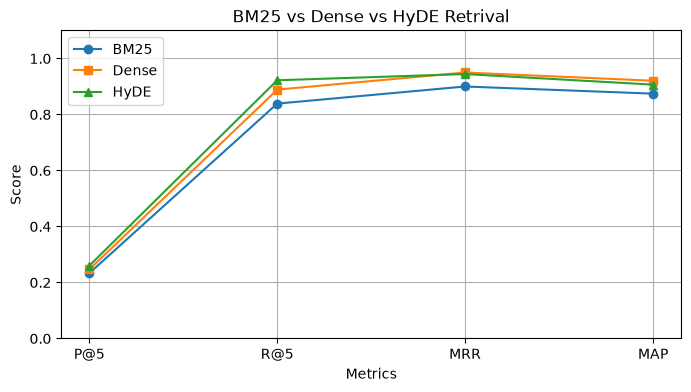

In [16]:
import matplotlib.pyplot as plt

metrics = ['P@5', 'R@5', 'MRR', 'MAP']
bm25_vals = [bm25_metrics['P@k'], bm25_metrics['R@k'], bm25_metrics['MRR'], bm25_metrics['MAP']]
dense_vals = [dense_metrics['P@k'], dense_metrics['R@k'], dense_metrics['MRR'], dense_metrics['MAP']]
hyde_vals = [hyde_metrics['P@k'], hyde_metrics['R@k'], hyde_metrics['MRR'], hyde_metrics['MAP']]

x = range(len(metrics))  # 0~3

plt.figure(figsize=(8, 4))
plt.plot(x, bm25_vals, marker='o', label='BM25')
plt.plot(x, dense_vals, marker='s', label='Dense')
plt.plot(x, hyde_vals, marker='^', label='HyDE')
plt.xticks(x, metrics)  # x축 눈금은 0~3 -> 지표명
plt.ylim(0, 1.1)
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('BM25 vs Dense vs HyDE Retrival')
plt.legend()
plt.grid()
plt.show()

##### HyDE의 역할과 효과
- HyDE는 쿼리를 “의미가 풍부한 가상문서”로 확장
- Dense가 이미 강력한 경우:
    - 성능을 보완하거나 유지
    - 항상 큰 폭의 개선을 보장하지는 않음
- 하지만 쿼리가 짧거나 모호한 경우, HyDE의 효과는 더욱 커질 가능성 있음

- Dense Retrieval은 의미 기반 검색의 기본 선택지
- HyDE는 다음 상황에서 특히 유용:
    - 짧고 추상적인 쿼리
    - 질문형 질의
    - Recall 개선이 중요한 경우
- 실서비스에서는: Dense + (HyDE / BM25 / Rerank) 조합이 가장 현실적인 접근